# Restaurant Clustering and Segmentation using Unsupervised Machine Learning

## Problem Statement

The objective of this project is to analyze Zomato restaurant data and segment restaurants into meaningful groups based on their characteristics such as cost and customer ratings. Unsupervised machine learning techniques are used to identify patterns and discover restaurant segments that can help businesses understand customer preferences and improve decision-making.

In [2]:
import matplotlib.pyplot as plt

## 1. Data Collection and Understanding

The project uses two datasets:

- Restaurant Dataset
- Restaurant Reviews Dataset

These datasets contain information about restaurant cost, cuisines, customer ratings, reviews, and other attributes required for clustering analysis.

In [3]:
import pandas as pd

restaurant_df = pd.read_excel("/Users/sidhi/Desktop/zomato/data/Zomato_restaurant_data.xlsx")
review_df = pd.read_excel("/Users/sidhi/Desktop/zomato/data/Zomato_restaurant_reviews.xlsx")


In [4]:
restaurant_df.head()
review_df.head()

restaurant_df.shape
review_df.shape

restaurant_df.info()
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    int64 
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Restaurant  10000 non-null  object        
 1   Reviewer    9962 non-null   object        
 2   Review      9955 non-null   object        
 3   Rating      9962 non-null   object        
 4   Metadata    9962 non-null   object        
 5   Time        9962 non-null   datetime64[ns]
 6   Pictures    10000 non-

## 2. Data Cleaning and Preprocessing

Before building clustering models, the datasets are cleaned by handling missing values, removing duplicate records, and preparing the data for further analysis.

In [5]:
restaurant_df.isnull().sum()

review_df.isnull().sum()

Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

In [6]:
restaurant_df.duplicated().sum()

np.int64(0)

In [7]:
review_df.duplicated().sum()

np.int64(36)

In [8]:
restaurant_df.nunique()

Name           105
Links          105
Cost            29
Collections     42
Cuisines        92
Timings         77
dtype: int64

In [9]:
review_df.nunique()

Restaurant     100
Reviewer      7446
Review        9364
Rating          10
Metadata      2477
Time          9782
Pictures        36
dtype: int64

In [10]:
restaurant_df = restaurant_df.drop_duplicates()
review_df = review_df.drop_duplicates()

In [11]:
restaurant_df.isnull().sum()
review_df.isnull().sum()

Restaurant    0
Reviewer      2
Review        9
Rating        2
Metadata      2
Time          2
Pictures      0
dtype: int64

In [12]:
restaurant_df['Collections'] = restaurant_df['Collections'].fillna('Unknown')
restaurant_df['Timings'] = restaurant_df['Timings'].fillna('Not Available')

review_df = review_df.dropna()

In [13]:
restaurant_df.isnull().sum()
review_df.isnull().sum()

Restaurant    0
Reviewer      0
Review        0
Rating        0
Metadata      0
Time          0
Pictures      0
dtype: int64

In [14]:
review_df.describe()

,Time,Pictures
count,9955,9955.000000
mean,2018-11-29 12:33:09.088900096,0.751984
min,2016-05-31 16:41:00,0.000000
25%,2018-08-12 00:10:30,0.000000
50%,2018-12-24 00:13:00,0.000000
75%,2019-03-31 20:10:00,0.000000
max,2019-05-25 20:23:00,64.000000
std,NaN,2.575691


In [15]:
restaurant_df.describe()

,Cost
count,105.000000
mean,861.428571
std,510.149730
min,150.000000
25%,500.000000
50%,700.000000
75%,1200.000000
max,2800.000000


# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the characteristics of restaurants, customer ratings, costs, cuisines, and review patterns. This step helps identify trends, patterns, and relationships in the data before applying clustering algorithms.

## Cost Distribution Analysis

This visualization shows how restaurant costs are distributed across the dataset.

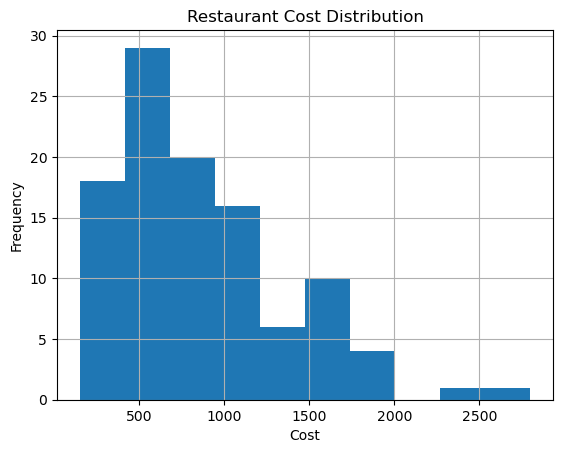

In [16]:
restaurant_df['Cost'].hist(bins=10)
plt.title("Restaurant Cost Distribution")
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.show()

## Cuisine Popularity Analysis

This analysis identifies the most frequently offered cuisines among restaurants.

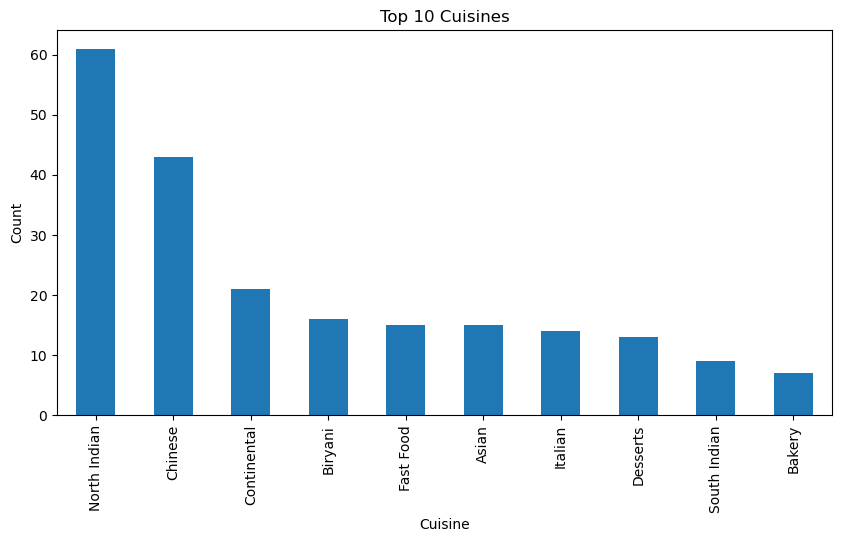

In [17]:
cuisines = restaurant_df['Cuisines'].str.split(',').explode().str.strip()

top_cuisines = cuisines.value_counts().head(10)

plt.figure(figsize=(10,5))
top_cuisines.plot(kind='bar')
plt.title("Top 10 Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Count")
plt.show()

## Average Restaurant Rating Analysis

This analysis examines average ratings across restaurants to understand customer satisfaction trends.

In [18]:
review_df['Rating'] = pd.to_numeric(review_df['Rating'], errors='coerce')

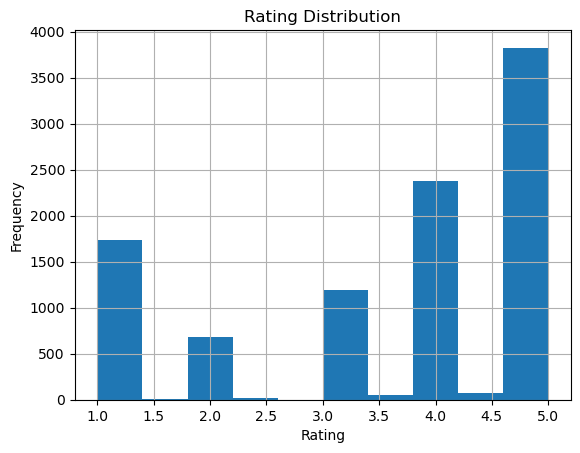

In [19]:
review_df['Rating'].hist(bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

## Most Reviewed Restaurants

This analysis highlights restaurants receiving the highest customer engagement through reviews.

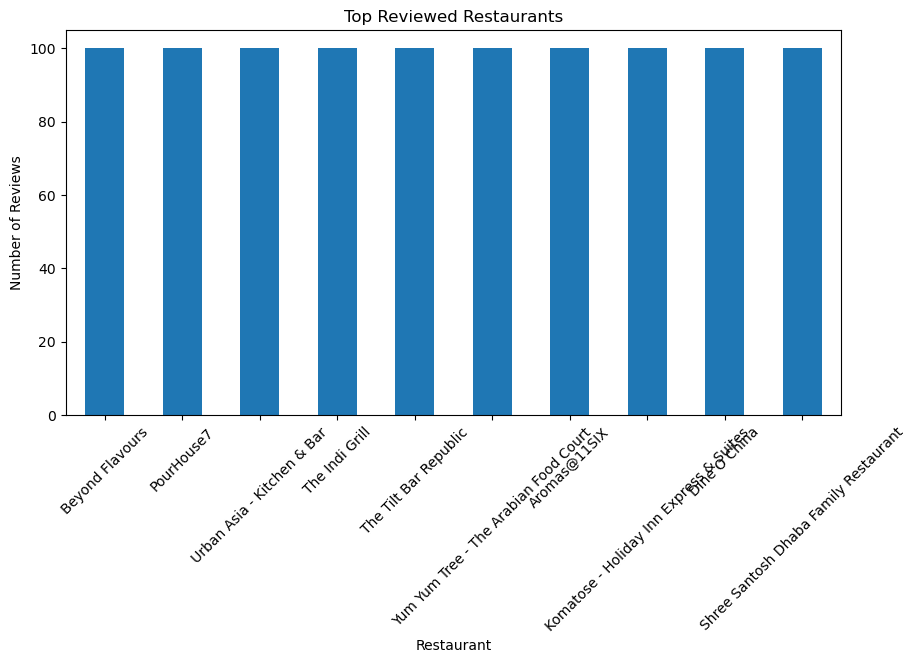

In [20]:
top_restaurants = review_df['Restaurant'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_restaurants.plot(kind='bar')
plt.title("Top Reviewed Restaurants")
plt.xlabel("Restaurant")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

## Rating Distribution Analysis

This visualization helps understand customer satisfaction levels across restaurants.

In [21]:
avg_rating_df = review_df.groupby('Restaurant')['Rating'].mean().reset_index()

merged_df = restaurant_df.merge(
    avg_rating_df,
    left_on='Name',
    right_on='Restaurant',
    how='inner'
)

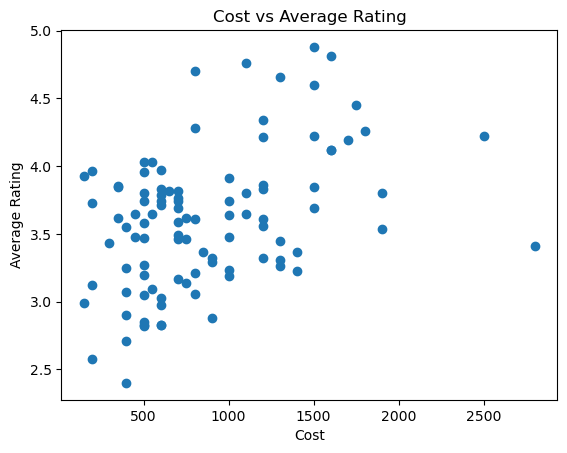

In [22]:
plt.scatter(merged_df['Cost'], merged_df['Rating'])
plt.title("Cost vs Average Rating")
plt.xlabel("Cost")
plt.ylabel("Average Rating")
plt.show()

# 4. Dataset Integration

The restaurant and review datasets were merged to create a unified dataset for clustering analysis.

In [23]:
avg_rating_df = review_df.groupby('Restaurant')['Rating'].mean().reset_index()
avg_rating_df.rename(columns={'Rating':'Avg_Rating'}, inplace=True)

In [24]:
merged_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Rating
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,4.28
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,Paradise,4.70
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",Flechazo,4.66
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,Shah Ghouse Hotel & Restaurant,3.21
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",Over The Moon Brew Company,4.34


# 5. Feature Selection

The features Cost and Average Rating were selected because they represent restaurant pricing and customer satisfaction, which are important factors for segmentation.

In [25]:
merged_df.rename(columns={'Rating':'Avg_Rating'}, inplace=True)
cluster_df = merged_df[['Cost','Avg_Rating']]

In [26]:
merged_df.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings',
       'Restaurant', 'Avg_Rating'],
      dtype='object')

# 6. Feature Scaling

Feature scaling was performed using StandardScaler to ensure all variables contribute equally to the clustering process.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

# 7. Determining Optimal Number of Clusters

The Elbow Method was used to determine the optimal number of clusters for K-Means Clustering.

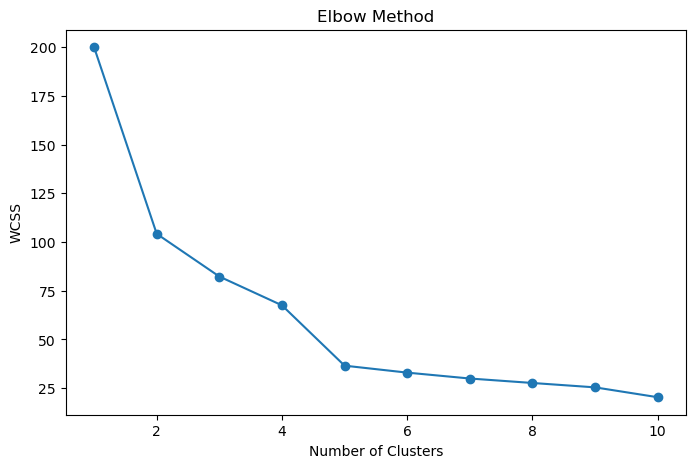

In [28]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# 8. K-Means Clustering

K-Means is a centroid-based clustering algorithm that groups similar restaurants together.

In [29]:





kmeans = KMeans(n_clusters=3, random_state=42)

merged_df['Cluster'] = kmeans.fit_predict(scaled_features)

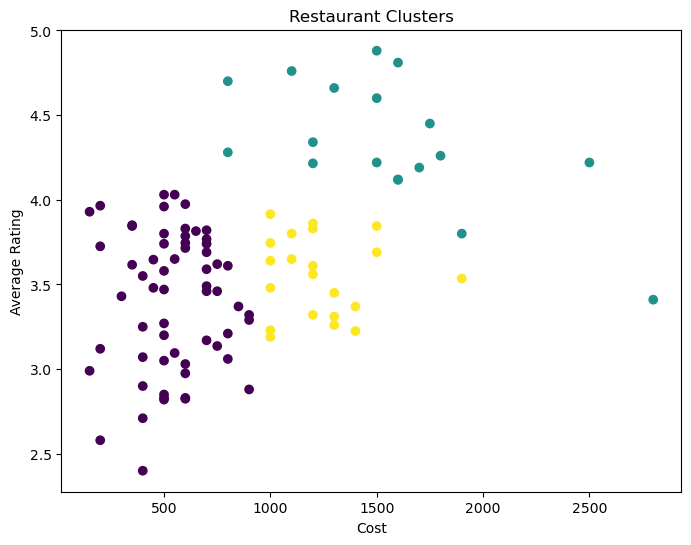

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged_df['Cost'],
    merged_df['Avg_Rating'],
    c=merged_df['Cluster']
)

plt.xlabel("Cost")
plt.ylabel("Average Rating")
plt.title("Restaurant Clusters")
plt.show()

In [31]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(
    scaled_features,
    merged_df['Cluster']
)

print("KMeans Silhouette Score:", kmeans_score)

KMeans Silhouette Score: 0.3342239454676504


# 9. Agglomerative Clustering

Agglomerative Clustering is a hierarchical clustering algorithm that builds clusters by progressively merging similar data points.

In [32]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)

merged_df['Agg_Cluster'] = agg.fit_predict(scaled_features)

In [33]:
from sklearn.metrics import silhouette_score

agg_score = silhouette_score(
    scaled_features,
    merged_df['Agg_Cluster']
)

print("Agglomerative Silhouette Score:", agg_score)

Agglomerative Silhouette Score: 0.370154727178012


# 10. DBSCAN Clustering

DBSCAN groups data points based on density and can identify noise or outlier observations.

In [34]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

merged_df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)

merged_df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    77
-1    17
 1     6
Name: count, dtype: int64

In [35]:
from sklearn.metrics import silhouette_score

dbscan_score = silhouette_score(
    scaled_features,
    merged_df['DBSCAN_Cluster']
)

print("DBSCAN Silhouette Score:", dbscan_score)

DBSCAN Silhouette Score: 0.3562042520775707


# 11. Model Comparison

The clustering algorithms were compared using the Silhouette Score to identify the best-performing model.

In [36]:
comparison = pd.DataFrame({
    'Model':['K-Means','Agglomerative','DBSCAN'],
    'Silhouette Score':[0.3342,0.3702,0.3562]
})

comparison.sort_values(
    by='Silhouette Score',
    ascending=False
)

,Model,Silhouette Score
1,Agglomerative,0.3702
2,DBSCAN,0.3562
0,K-Means,0.3342


# 12. Cluster Interpretation

The clusters identified by Agglomerative Clustering were analyzed based on average cost and average rating.

In [37]:
merged_df.groupby('Agg_Cluster')[
['Cost','Avg_Rating']
].mean()

,Cost,Avg_Rating
Agg_Cluster,,
0,760.833333,3.588178
1,1573.809524,4.242983
2,447.368421,2.936616


### Cluster Analysis

- Cluster 0 consists of mid-range restaurants with an average cost of approximately ₹761 and an average rating of 3.59. These restaurants offer moderate pricing and average customer satisfaction.

- Cluster 1 consists of premium restaurants with an average cost of approximately ₹1574 and the highest average rating of 4.24. This segment represents high-quality dining experiences and premium establishments.

- Cluster 2 consists of budget restaurants with an average cost of approximately ₹447 and the lowest average rating of 2.94. These restaurants are affordable but generally receive lower customer ratings.

# 13. Business Insights

- Cluster 1 represents premium restaurants with the highest ratings.
- Cluster 0 represents mid-range restaurants with average ratings.
- Cluster 2 represents budget restaurants with lower ratings.
- Higher-priced restaurants generally received better customer ratings.

# 14. Conclusion

Three clustering algorithms—K-Means, Agglomerative Clustering, and DBSCAN—were applied to segment restaurants based on cost and average ratings.

Agglomerative Clustering achieved the highest Silhouette Score of 0.3702 and was selected as the best model.

The clustering process identified premium, mid-range, and budget restaurant segments, providing valuable insights for business decision-making and customer targeting.

# Restaurant Segment Prediction

After identifying restaurant clusters using K-Means, the trained model was saved and reused for prediction.

This section demonstrates a practical application of clustering by allowing users to input restaurant characteristics and automatically determine which customer segment the restaurant belongs to.

Inputs:
- Restaurant Cost
- Average Rating

Output:
- Budget Restaurant
- Mid-Range Restaurant
- Premium Restaurant

This simulates how businesses can classify new restaurants without retraining the model.

In [38]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model Saved Successfully")

Model Saved Successfully


In [42]:
import pandas as pd
import joblib

# Load model and scaler
model = joblib.load("kmeans_model.pkl")
scaler = joblib.load("scaler.pkl")

print("=" * 38)
print(" ZOMATO RESTAURANT SEGMENT PREDICTOR ")
print("=" * 38)

cost = float(input("Enter Restaurant Cost: "))
rating = float(input("Enter Average Rating: "))

# Create dataframe with feature names
new_data = pd.DataFrame({
    "Cost": [cost],
    "Avg_Rating": [rating]
})

scaled_data = scaler.transform(new_data)

cluster = model.predict(scaled_data)[0]

cluster_names = {
    0: "Mid-Range Restaurant",
    1: "Premium Restaurant",
    2: "Budget Restaurant"
}

print("\nPredicted Segment:")
print(cluster_names[cluster])

print("\nThank you for using Zomato Restaurant Segment Predictor")

 ZOMATO RESTAURANT SEGMENT PREDICTOR 


Enter Restaurant Cost:  1500
Enter Average Rating:  5



Predicted Segment:
Premium Restaurant

Thank you for using Zomato Restaurant Segment Predictor


# Prediction Results and Business Impact

The saved K-Means clustering model successfully classified new restaurant data into predefined market segments.

Business Benefits:
- Helps restaurant owners understand their market positioning.
- Assists food delivery platforms in customer targeting.
- Supports pricing and marketing decisions.
- Enables automatic categorization of newly added restaurants.

Example:
A restaurant with a cost of 300 and rating of 4.0 was classified as a Mid-Range Restaurant, indicating moderate pricing with good customer satisfaction.

This demonstrates how clustering can be deployed as a simple decision-support system for restaurant segmentation.